# 05 — BM25+ Degradation Analysis

Diagnoses **why BM25+ retrieval performance changes across popularity deciles**.

Each section tests a specific hypothesis using the enriched BM25+ results DataFrame
and the `bm25_analysis` module.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.retrieval_gold_document_eval.shared_setup import *
from src.metrics.bm25_analysis import *
from src.metrics.decile_utils import boundaries_for
from config import ROOT_DIR

BM25_KEY = 'retrieved_docs_bm25_plus'
df = results_by_strategy[BM25_KEY].copy()
boundaries = boundaries_for(DECILE_MODE, boundaries_uw, boundaries_cw)
print(f'BM25+ rows: {len(df):,}')
print(f'Decile col: {decile_col}')
print(f'Score examples: {df.iloc[0]["topk_scores"][:3]}')
print(f'Has doc_length: {"doc_length" in df.columns}')

PAPER_FIGURES_DIR = ROOT_DIR / 'paper_figures'
PAPER_FIGURES_DIR.mkdir(exist_ok=True)

✓ Boundaries loaded (UW: 1.0000…175763168.0000)
  ✓ BM25+: loading from cache
    excluded 1,325 rows matching EXCLUDED_DATASETS (['hotpot_qa'])
  ✓ FAISS high: loading from cache
    excluded 1,325 rows matching EXCLUDED_DATASETS (['hotpot_qa'])
  ✓ FAISS hybrid: loading from cache
    excluded 1,325 rows matching EXCLUDED_DATASETS (['hotpot_qa'])
✓ Metrics loaded from cache
✓ Per-decile metrics loaded from cache

✓ shared_setup complete — 3 strategies ready
  Corpus root: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil
  Results dir: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
    'BM25+' (key=retrieved_docs_bm25_plus)
    'FAISS high' (key=retrieved_docs_ivfpq_high)
    'FAISS hybrid' (key=retrieved_docs_faiss_hybrid)
  Decile mode: chunk_weighted
  Group col  : dataset
BM25+ rows: 6,058
Decile col: pop_decile_chunk_weighted
Score examples: [None None None]
Has doc_length: True


## 1. Random-Chunk Target-Article Baseline

**Question:** How likely is a randomly selected indexed chunk to belong to the target article?

For each question, this is `target_article_chunks / all_indexed_chunks`.
The per-decile mean isolates index exposure: popular target articles have
more chunks, so a random chunk is more likely to belong to them.

In [2]:
gap_df = compute_score_gap_by_decile(df, decile_col, top_k=TOP_K)
print(gap_df.to_string(index=False, float_format='%.4f'))

 decile  count  hit_rate  mean_gold_score  mean_top1_score  mean_score_gap  mean_score_ratio
      0    357    0.7087              NaN              NaN             NaN               NaN
      1    502    0.5717              NaN              NaN             NaN               NaN
      2    617    0.5802              NaN              NaN             NaN               NaN
      3    646    0.5759              NaN              NaN             NaN               NaN
      4    649    0.5824              NaN              NaN             NaN               NaN
      5    646    0.5681              NaN              NaN             NaN               NaN
      6    655    0.5679              NaN              NaN             NaN               NaN
      7    660    0.5333              NaN              NaN             NaN               NaN
      8    662    0.5378              NaN              NaN             NaN               NaN
      9    664    0.5045              NaN              NaN            

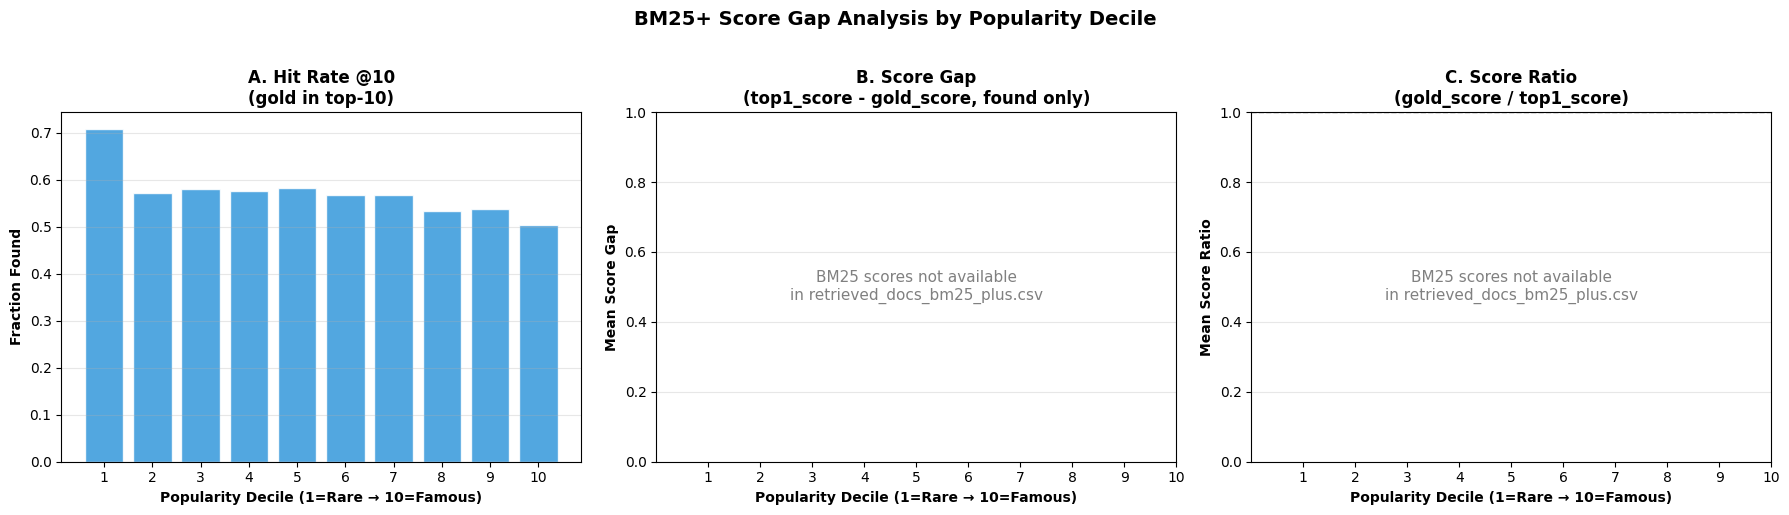

✓ Saved → bm25_score_gap_by_decile.png


In [3]:
baseline_path = RESULTS_DIR / f'bm25_lexical_factors_v2_{BM25_KEY}_{DECILE_MODE}.parquet'
baseline_df = pd.read_parquet(baseline_path)
random_chunk_baseline = (
    baseline_df.groupby('decile', as_index=False)['n_chunks'].mean()
    .assign(random_chunk_target_article_hit_pct=lambda data: data['n_chunks'] / corpus_chunks.sum() * 100)
)

d_idx = random_chunk_baseline['decile'] + 1
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d_idx, random_chunk_baseline['random_chunk_target_article_hit_pct'], color='#E69F00', marker='s', linewidth=2, markersize=6)
ax.set_title('Random-Chunk Target-Article Hit Probability', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontweight='bold')
ax.set_ylabel('Probability of a Correct Random Chunk (%)', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
out = PAPER_FIGURES_DIR / 'random_chunk_target_article_hit_probability_by_chunk_weighted_decile.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 2. Popularity Displacement Analysis

**Question:** What types of documents displace the gold doc when it's not found?

Compares the gold doc's popularity to the mean popularity of retrieved docs.
If BM25+ systematically retrieves **more popular** docs, those are the
competitors pushing the gold doc out of the top-k.

In [4]:
disp_df = compute_popularity_displacement(df, decile_col, top_k=TOP_K)
print(disp_df.to_string(index=False, float_format='%.4f'))

 decile  count  mean_gold_pop  mean_retrieved_pop  mean_pop_ratio  mean_n_more_popular  mean_n_less_popular
      0    357        12.8557           4460.2759        704.5457               8.1541               1.0364
      1    502        40.1073           4593.6992        116.9326               7.6912               1.5896
      2    617        82.3191           9554.8836        137.1585               6.7828               2.5494
      3    646       163.2015           5697.6056         35.9591               6.1146               3.2585
      4    649       311.9370           5419.5097         17.7414               5.0940               4.0770
      5    646       606.7277           7598.7194         13.0418               4.2678               4.7709
      6    655      1202.7884           8231.4736          7.3067               3.6672               5.4779
      7    660      2584.4031           9409.3144          3.8349               2.9273               6.2136
      8    662      7162.051

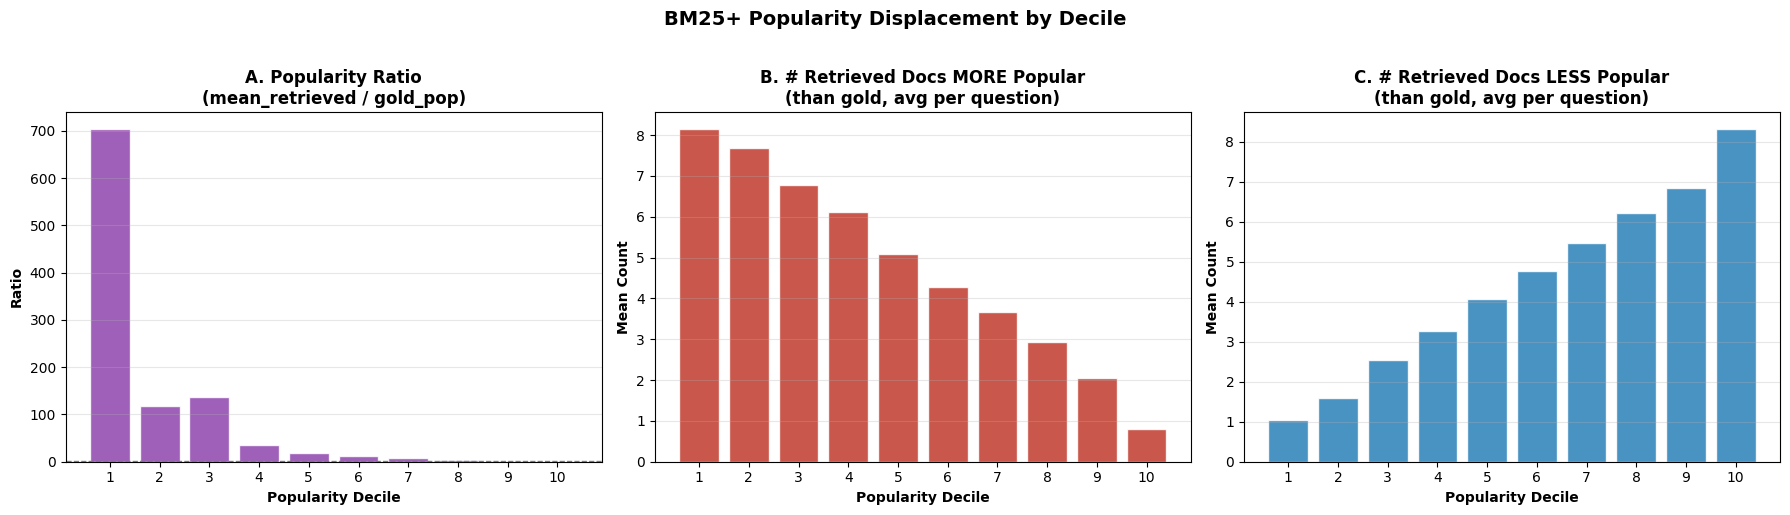

✓ Saved → bm25_popularity_displacement.png


In [5]:
d_idx = disp_df['decile'] + 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — Popularity ratio
ax = axes[0]
ax.bar(d_idx, disp_df['mean_pop_ratio'], color='#8e44ad', alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax.set_title('A. Popularity Ratio\n(mean_retrieved / gold_pop)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Ratio', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

# Panel B — # more popular retrieved
ax = axes[1]
ax.bar(d_idx, disp_df['mean_n_more_popular'], color='#c0392b', alpha=0.85, edgecolor='white')
ax.set_title('B. # Retrieved Docs MORE Popular\n(than gold, avg per question)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Mean Count', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

# Panel C — # less popular retrieved
ax = axes[2]
ax.bar(d_idx, disp_df['mean_n_less_popular'], color='#2980b9', alpha=0.85, edgecolor='white')
ax.set_title('C. # Retrieved Docs LESS Popular\n(than gold, avg per question)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Mean Count', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('BM25+ Popularity Displacement by Decile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'bm25_popularity_displacement.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 3. Gold Document Rank Distribution

**Question:** When the gold doc IS found, where does it typically rank?

Shows the fraction of questions where gold appears at rank 1, 2, ..., 10
vs not found at all.  If popular docs are systematically pushed to lower
ranks, that explains the recall degradation.

In [6]:
rank_df = compute_rank_distribution_by_decile(df, decile_col, top_k=TOP_K)
print(rank_df[['decile', 'count', 'frac_not_found', 'frac_rank_1', 'frac_rank_2', 'frac_rank_3',
               'mean_rank_found', 'median_rank_found']].to_string(index=False, float_format='%.4f'))

 decile  count  frac_not_found  frac_rank_1  frac_rank_2  frac_rank_3  mean_rank_found  median_rank_found
      0    357          0.2129       0.4818       0.0952       0.0504           4.7082             1.0000
      1    502          0.3307       0.3705       0.0657       0.0478           6.3363             1.0000
      2    617          0.3063       0.3290       0.0924       0.0567           6.4626             2.0000
      3    646          0.3034       0.3498       0.0882       0.0418           6.4867             1.0000
      4    649          0.3066       0.3097       0.1356       0.0416           6.1356             2.0000
      5    646          0.3003       0.3158       0.1053       0.0464           6.7212             2.0000
      6    655          0.3008       0.2901       0.1298       0.0290           7.4585             2.0000
      7    660          0.3121       0.2242       0.0985       0.0576           8.3568             3.0000
      8    662          0.3112       0.2251   

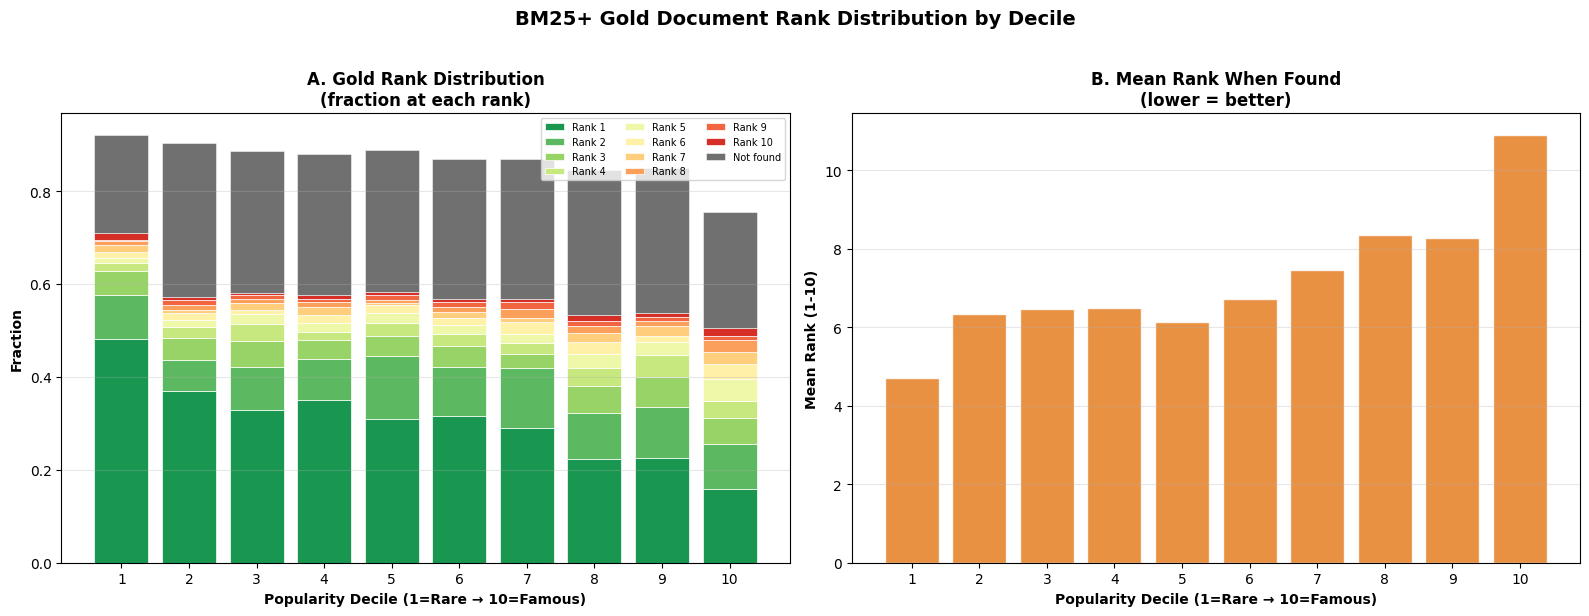

✓ Saved → bm25_rank_distribution.png


In [7]:
d_idx = rank_df['decile'] + 1
rank_cols = [f'frac_rank_{k}' for k in range(1, TOP_K + 1)]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rank_cols)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A — Stacked bar of rank fractions
ax = axes[0]
bottom = np.zeros(len(rank_df))
for i, col in enumerate(rank_cols):
    vals = rank_df[col].values
    ax.bar(d_idx, vals, bottom=bottom, color=colors[i], edgecolor='white',
           linewidth=0.5, label=f'Rank {i+1}')
    bottom += vals
ax.bar(d_idx, rank_df['frac_not_found'], bottom=bottom, color='#333333',
       alpha=0.7, edgecolor='white', linewidth=0.5, label='Not found')
ax.set_title('A. Gold Rank Distribution\n(fraction at each rank)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontweight='bold')
ax.set_ylabel('Fraction', fontweight='bold')
ax.set_xticks(d_idx)
ax.legend(fontsize=7, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Panel B — Mean rank when found
ax = axes[1]
valid = rank_df['mean_rank_found'].notna()
ax.bar(d_idx[valid.values], rank_df.loc[valid, 'mean_rank_found'],
       color='#e67e22', alpha=0.85, edgecolor='white')
ax.set_title('B. Mean Rank When Found\n(lower = better)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontweight='bold')
ax.set_ylabel('Mean Rank (1-10)', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('BM25+ Gold Document Rank Distribution by Decile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'bm25_rank_distribution.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 4. Competition Analysis

**Question:** How much competition does each decile face in the index?

Popular articles have far more chunks in the index.  This means:
- More competing chunks from the same popularity stratum
- More noise per query (irrelevant chunks that partially match)

The **competition index** = `n_chunks / n_questions` — higher values mean
each question faces more competing chunks.

In [8]:
questions_per_decile = np.array(
    [int((df[decile_col] == d).sum()) for d in range(10)], dtype=float
)
comp_df = compute_competition_stats(corpus_docs, corpus_chunks, questions_per_decile)
print(comp_df.to_string(index=False, float_format='%.2f'))

 decile  n_docs  n_chunks  n_questions  chunks_per_doc  chunks_per_question  random_doc_hit_rate  random_chunk_hit_rate  competition_index
      0 1684580   2463538          357            1.46              6900.67                 0.00                   0.00            6900.67
      1 1007485   2465757          502            2.45              4911.87                 0.00                   0.00            4911.87
      2  775596   2466181          617            3.18              3997.05                 0.00                   0.00            3997.05
      3  629980   2465179          646            3.91              3816.07                 0.00                   0.00            3816.07
      4  513899   2465263          649            4.80              3798.56                 0.00                   0.00            3798.56
      5  417882   2465226          646            5.90              3816.14                 0.00                   0.00            3816.14
      6  331641   2465236  

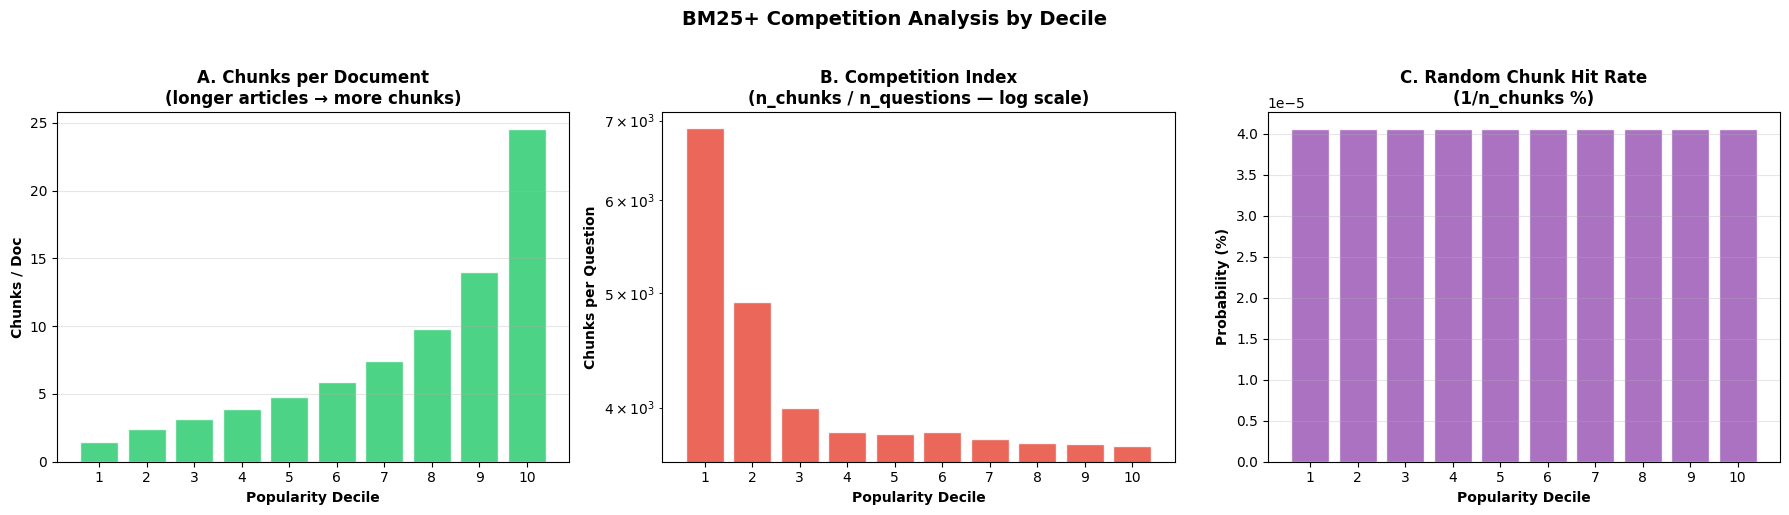

✓ Saved → bm25_competition_analysis.png


In [9]:
d_idx = comp_df['decile'] + 1
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(d_idx, comp_df['chunks_per_doc'], color='#0072B2', marker='o', linewidth=2, markersize=6)
ax.set_title('Mean Chunks per Article by Chunk-Weighted Popularity Decile', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile (1=Rare → 10=Famous)', fontweight='bold')
ax.set_ylabel('Mean Chunks per Article', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
out = PAPER_FIGURES_DIR / 'mean_chunks_per_article_by_chunk_weighted_decile.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 5. BM25 Score vs Document Length

**Question:** Does BM25+'s length normalization systematically penalise
popular (longer) documents?

BM25 uses a length-normalization parameter `b` (default 0.75) that
penalizes documents longer than the corpus average.  Since popular
articles are much longer, their per-term scores may be diluted.

Note: BM25+ indexes **chunks** (1000 chars each), so individual chunks
are similar in length.  The effect here is indirect — longer docs
produce more chunks, increasing competition.

In [10]:
slen_df = compute_score_vs_length_by_decile(df, decile_col, top_k=TOP_K)
print(slen_df.to_string(index=False, float_format='%.2f'))

 decile  count  mean_top1_score  mean_gold_score_if_found  mean_gold_doc_length
      0    357              NaN                       NaN               2106.68
      1    502              NaN                       NaN               3726.20
      2    617              NaN                       NaN               2634.20
      3    646              NaN                       NaN               2836.37
      4    649              NaN                       NaN               3544.94
      5    646              NaN                       NaN               4796.40
      6    655              NaN                       NaN               6136.52
      7    660              NaN                       NaN               7876.23
      8    662              NaN                       NaN              12395.27
      9    664              NaN                       NaN              31333.02


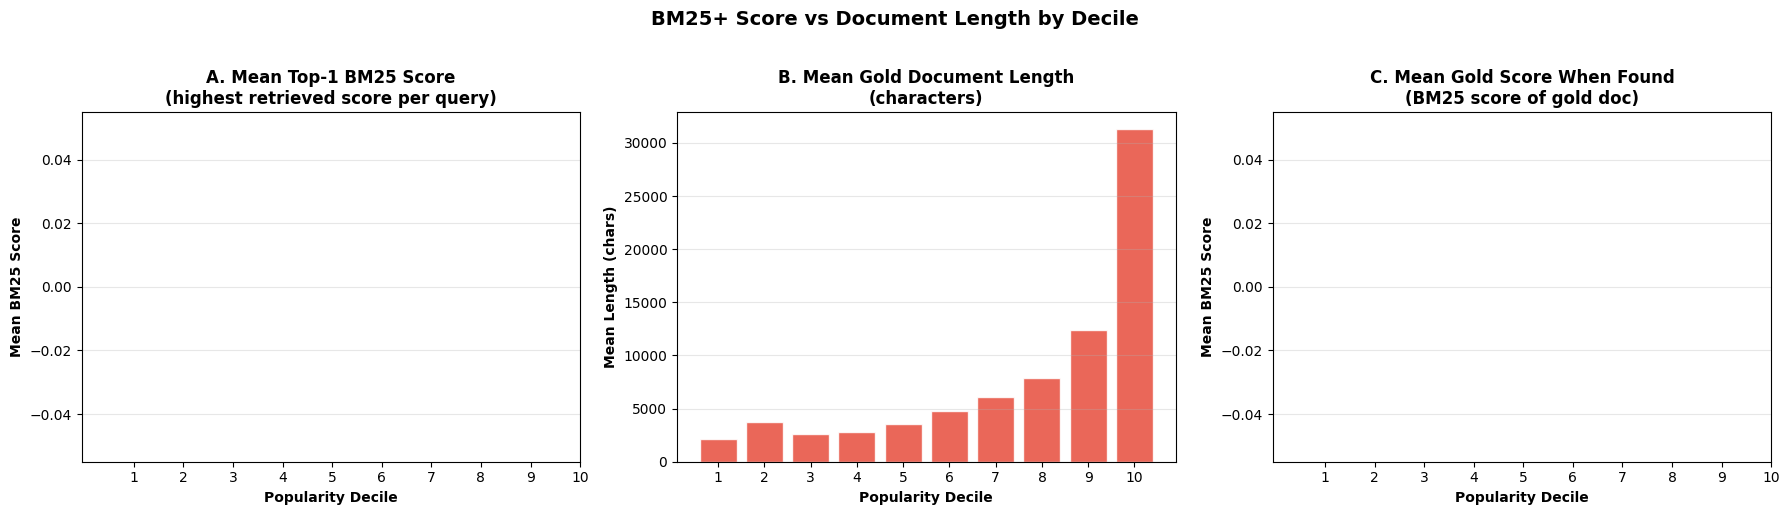

✓ Saved → bm25_score_vs_length.png


In [11]:
d_idx = slen_df['decile'] + 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — Top-1 BM25 score
ax = axes[0]
ax.bar(d_idx, slen_df['mean_top1_score'], color='#3498db', alpha=0.85, edgecolor='white')
ax.set_title('A. Mean Top-1 BM25 Score\n(highest retrieved score per query)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Mean BM25 Score', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

# Panel B — Gold doc length
ax = axes[1]
ax.bar(d_idx, slen_df['mean_gold_doc_length'], color='#e74c3c', alpha=0.85, edgecolor='white')
ax.set_title('B. Mean Gold Document Length\n(characters)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Mean Length (chars)', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

# Panel C — Gold score when found
ax = axes[2]
valid = slen_df['mean_gold_score_if_found'].notna()
ax.bar(d_idx[valid.values], slen_df.loc[valid, 'mean_gold_score_if_found'],
       color='#27ae60', alpha=0.85, edgecolor='white')
ax.set_title('C. Mean Gold Score When Found\n(BM25 score of gold doc)', fontweight='bold', fontsize=12)
ax.set_xlabel('Popularity Decile', fontweight='bold')
ax.set_ylabel('Mean BM25 Score', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('BM25+ Score vs Document Length by Decile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'bm25_score_vs_length.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 6. Retrieved Set Composition

**Question:** What popularity strata do BM25+'s retrieved documents come from?

If BM25+ retrieves documents from **the same or higher deciles** than the
gold doc, those are the competitors.  If it retrieves from **lower**
deciles, that suggests term overlap with rare-doc topics.

Key metric: `mean_retrieved_decile` — if this is above the gold decile,
BM25+ is biased toward more popular documents.

In [12]:
comp2_df = compute_retrieved_composition_by_decile(df, decile_col, boundaries, top_k=TOP_K)
print(comp2_df.to_string(index=False, float_format='%.4f'))

 decile  count  mean_frac_same_decile  mean_frac_higher_decile  mean_frac_lower_decile  mean_retrieved_decile
      0    357                 0.2637                   0.7363                  0.0000                 3.3997
      1    502                 0.1868                   0.7179                  0.0952                 3.9837
      2    617                 0.1821                   0.6215                  0.1964                 4.1612
      3    646                 0.1875                   0.5544                  0.2581                 4.3845
      4    649                 0.1963                   0.4602                  0.3435                 4.5171
      5    646                 0.1946                   0.3848                  0.4206                 4.8015
      6    655                 0.2060                   0.3090                  0.4850                 5.0435
      7    660                 0.1973                   0.2381                  0.5646                 5.3349
      8   

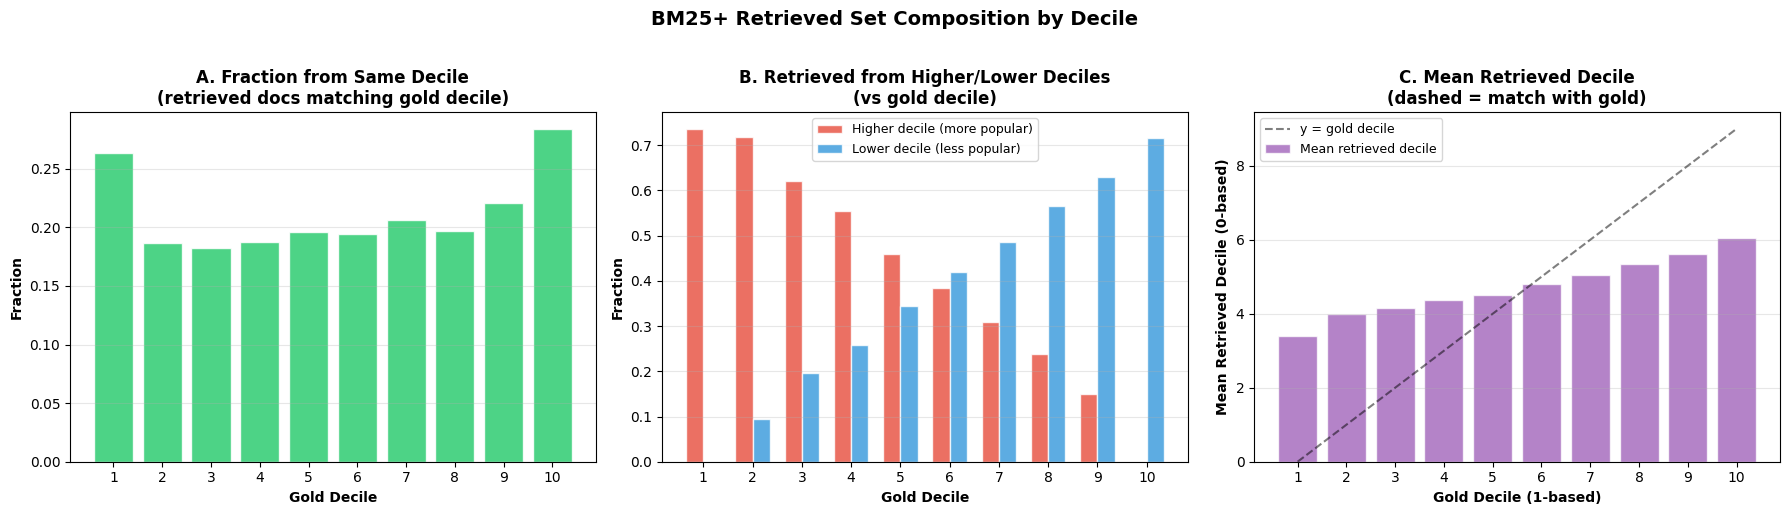

✓ Saved → bm25_retrieved_composition.png


In [13]:
d_idx = comp2_df['decile'] + 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A — Fraction same decile
ax = axes[0]
ax.bar(d_idx, comp2_df['mean_frac_same_decile'], color='#2ecc71', alpha=0.85, edgecolor='white')
ax.set_title('A. Fraction from Same Decile\n(retrieved docs matching gold decile)', fontweight='bold', fontsize=12)
ax.set_xlabel('Gold Decile', fontweight='bold')
ax.set_ylabel('Fraction', fontweight='bold')
ax.set_xticks(d_idx)
ax.grid(axis='y', alpha=0.3)

# Panel B — Fraction higher / lower
ax = axes[1]
w = 0.35
ax.bar(d_idx - w/2, comp2_df['mean_frac_higher_decile'], w, color='#e74c3c',
       alpha=0.80, edgecolor='white', label='Higher decile (more popular)')
ax.bar(d_idx + w/2, comp2_df['mean_frac_lower_decile'], w, color='#3498db',
       alpha=0.80, edgecolor='white', label='Lower decile (less popular)')
ax.set_title('B. Retrieved from Higher/Lower Deciles\n(vs gold decile)', fontweight='bold', fontsize=12)
ax.set_xlabel('Gold Decile', fontweight='bold')
ax.set_ylabel('Fraction', fontweight='bold')
ax.set_xticks(d_idx)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel C — Mean retrieved decile vs gold decile
ax = axes[2]
ax.plot([1, 10], [0, 9], 'k--', alpha=0.5, label='y = gold decile')
ax.bar(d_idx, comp2_df['mean_retrieved_decile'], color='#9b59b6', alpha=0.75,
       edgecolor='white', label='Mean retrieved decile')
ax.set_title('C. Mean Retrieved Decile\n(dashed = match with gold)', fontweight='bold', fontsize=12)
ax.set_xlabel('Gold Decile (1-based)', fontweight='bold')
ax.set_ylabel('Mean Retrieved Decile (0-based)', fontweight='bold')
ax.set_xticks(d_idx)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('BM25+ Retrieved Set Composition by Decile', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'bm25_retrieved_composition.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 7. BM25 Score vs Gold Popularity (Per-Question Scatter)

**Question:** Is there a continuous relationship between the gold doc's
popularity and the BM25+ top-1 score?

This reveals whether the degradation is gradual or threshold-based.

ValueError: bins must increase monotonically.

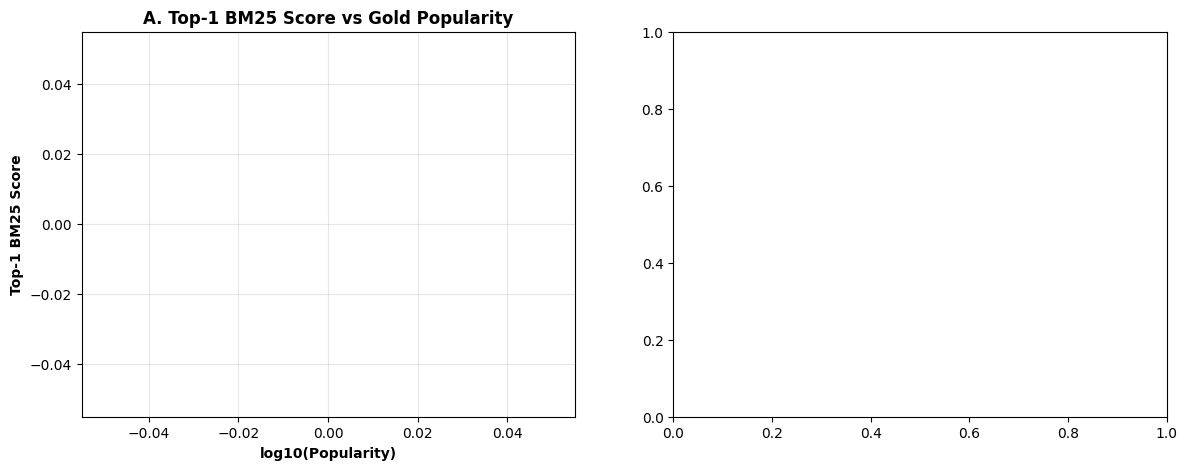

In [14]:
df_valid = df.dropna(subset=['doc_length']).copy()
df_valid['log_pop'] = np.log10(df_valid['popularity_avg'].clip(lower=1e-1))

# Extract top-1 scores
def _top1(row):
    s = row.get('topk_scores')
    if s is None or len(s) == 0:
        return np.nan
    if s[0] is None or pd.isna(s[0]):
        return np.nan
    v = float(s[0])
    return v if not np.isnan(v) else np.nan

df_valid['top1_score'] = df_valid.apply(_top1, axis=1)
df_valid = df_valid.dropna(subset=['top1_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A — Scatter: top1 score vs log popularity
ax = axes[0]
colors = plt.cm.viridis(df_valid[decile_col] / 9.0)
ax.scatter(df_valid['log_pop'], df_valid['top1_score'], s=3, alpha=0.25, c=colors)
ax.set_xlabel('log10(Popularity)', fontweight='bold')
ax.set_ylabel('Top-1 BM25 Score', fontweight='bold')
ax.set_title('A. Top-1 BM25 Score vs Gold Popularity', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Add binned means
bins = np.linspace(df_valid['log_pop'].min(), df_valid['log_pop'].max(), 25)
df_valid['pop_bin'] = pd.cut(df_valid['log_pop'], bins=bins, labels=False)
binned = df_valid.groupby('pop_bin').agg(
    x=('log_pop', 'mean'),
    y=('top1_score', 'mean'),
    ci=('top1_score', lambda s: 1.96 * s.std() / np.sqrt(len(s)) if len(s) > 1 else 0),
).dropna()
ax.errorbar(binned['x'], binned['y'], yerr=binned['ci'], fmt='-o', color='red',
             markersize=4, linewidth=2, capsize=3, label='Binned mean ± 95% CI')
ax.legend(fontsize=9)

# Panel B — Scatter: gold doc length vs top1 score
ax = axes[1]
ax.scatter(df_valid['doc_length'], df_valid['top1_score'], s=3, alpha=0.25, c=colors)
ax.set_xlabel('Gold Document Length (chars)', fontweight='bold')
ax.set_ylabel('Top-1 BM25 Score', fontweight='bold')
ax.set_title('B. Top-1 BM25 Score vs Gold Doc Length', fontweight='bold', fontsize=12)
ax.set_xscale('log')
ax.grid(alpha=0.3)

bins_len = np.logspace(
    np.log10(df_valid['doc_length'].clip(lower=1).min()),
    np.log10(df_valid['doc_length'].max()), 25,
)
df_valid['len_bin'] = pd.cut(df_valid['doc_length'], bins=bins_len, labels=False)
binned_len = df_valid.groupby('len_bin').agg(
    x=('doc_length', 'mean'),
    y=('top1_score', 'mean'),
    ci=('top1_score', lambda s: 1.96 * s.std() / np.sqrt(len(s)) if len(s) > 1 else 0),
).dropna()
ax.errorbar(binned_len['x'], binned_len['y'], yerr=binned_len['ci'], fmt='-o', color='red',
             markersize=4, linewidth=2, capsize=3, label='Binned mean ± 95% CI')
ax.legend(fontsize=9)

fig.suptitle('BM25+ Score vs Popularity & Length (Per-Question)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
out = IMAGES_DIR / 'bm25_score_scatter.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved → {out.name}')

## 8. Master Diagnostic Table

Combines all analyses into one summary table for quick comparison.

In [ ]:
diag = compute_bm25_diagnostic_table(
    df, decile_col, corpus_docs, corpus_chunks, boundaries, top_k=TOP_K,
)
# Select key columns for display
display_cols = [
    'decile', 'n_docs', 'n_chunks', 'chunks_per_doc',
    'hit_rate', 'mean_score_gap', 'mean_score_ratio',
    'mean_pop_ratio', 'mean_n_more_popular',
    'mean_top1_score', 'mean_gold_doc_length',
]
display_cols = [c for c in display_cols if c in diag.columns]
diag_display = diag[display_cols].copy()
diag_display['decile'] += 1
print(diag_display.to_string(index=False, float_format='%.3f'))

out = IMAGES_DIR / 'bm25_diagnostic_table.csv'
diag_display.to_csv(out, index=False, float_format='%.4f')
print(f'\n✓ Saved → {out.name}')